In [63]:
import torch
from torchvision import datasets, transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18
from torch.utils.data import DataLoader, TensorDataset, Dataset, Subset
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import random
from torchvision.datasets import CIFAR10

In [2]:
trainTransform = transforms.Compose([transforms.ToTensor()])
testTransform = transforms.Compose([transforms.ToTensor()])

trainSet = CIFAR10(root="./data", train=True, download=True, transform=trainTransform)
testSet = CIFAR10(root="./data", train=False, download=True, transform=testTransform)
trainLoader = DataLoader(trainSet, batch_size=128, shuffle=True, num_workers=0)
testLoader = DataLoader(testSet, batch_size=128, shuffle=False, num_workers=0)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.feature_extractor(x)
        features = torch.flatten(features, 1)
        output = self.classifier(features)
        return output
    
    def getEmbeddings(self, x):
        features = self.feature_extractor(x)
        features = torch.flatten(features, 1)
        features = F.normalize(features, p=2, dim=1)
        return features
    

In [4]:
class ResNet18Classifier(nn.Module):
    def __init__(self, numClasses=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, numClasses)

    def forward(self, x):
        return self.backbone(x)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def trainResNetClassifier(model, trainLoader, numEpochs=10):
    model = model.to(device)
    lossFn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(numEpochs):
        model.train()
        runningLoss = 0.0
        correct = 0
        total = 0

        for images, labels in trainLoader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = lossFn(logits, labels)
            loss.backward()
            optimizer.step()

            runningLoss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epochLoss = runningLoss / len(trainLoader)
        epochAcc = correct / total
        print(f"Epoch {epoch + 1}/{numEpochs}, Loss: {epochLoss:.4f}, Train Acc: {epochAcc:.4f}")

    return model

cpu


In [24]:
def evaluateClassifier(model, testLoader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    testAccuracy = correct / total
    return testAccuracy

In [25]:
resnetModel = ResNet18Classifier(numClasses=10).to(device)
resnetModel = trainResNetClassifier(resnetModel, trainLoader, numEpochs=10)

testAcc = evaluateClassifier(resnetModel, testLoader)
print("Full ResNet test accuracy:", testAcc)

torch.save(resnetModel.state_dict(), "resnet18Cifar10.pth")

Epoch 1/10, Loss: 1.3685, Train Acc: 0.5062
Epoch 2/10, Loss: 0.9853, Train Acc: 0.6510
Epoch 3/10, Loss: 0.8088, Train Acc: 0.7139
Epoch 4/10, Loss: 0.6914, Train Acc: 0.7559
Epoch 5/10, Loss: 0.5959, Train Acc: 0.7915
Epoch 6/10, Loss: 0.5100, Train Acc: 0.8209
Epoch 7/10, Loss: 0.4386, Train Acc: 0.8459
Epoch 8/10, Loss: 0.3746, Train Acc: 0.8691
Epoch 9/10, Loss: 0.3231, Train Acc: 0.8877
Epoch 10/10, Loss: 0.2654, Train Acc: 0.9079
Full ResNet test accuracy: 0.6518


In [38]:
class ResNet18FeatureExtractor(nn.Module):
    def __init__(self, trainedModel):
        super().__init__()
        self.features = nn.Sequential(*list(trainedModel.backbone.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnetModel = ResNet18Classifier(numClasses=10).to(device)
resnetModel.load_state_dict(torch.load("resnet18Cifar10.pth", map_location=device))
resnetModel.eval()
featureExtractor = ResNet18FeatureExtractor(resnetModel).to(device)
featureExtractor.eval()

/var/folders/h4/l90wkg5j0dz27gsv50bz6f000000gn/T/ipykernel_74979/2245030857.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnetModel.load_state_dict(torch.load("resne

ResNet18FeatureExtractor(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [40]:
def extract_embeddings(model, dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
    model.eval()

    allEmbeddings = []
    allLabels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model(images)
            allEmbeddings.append(features.cpu())
            allLabels.append(labels)

    allEmbeddings = torch.cat(allEmbeddings, dim=0)
    allLabels = torch.cat(allLabels, dim=0)

    return allEmbeddings, allLabels

trainEmbeddings, trainLabels = extract_embeddings(featureExtractor, trainSet)
testEmbeddings, testLabels = extract_embeddings(featureExtractor, testSet)
torch.save(trainEmbeddings, "train_embeddings.pt")
torch.save(trainLabels, "train_labels.pt")
torch.save(testEmbeddings, "test_embeddings.pt")
torch.save(testLabels, "test_labels.pt")

In [41]:
def computeTypicality(clusterEmbeddings, kNeighbors=20):
    clusterEmbeddingsNp = clusterEmbeddings.cpu().numpy()
    n = len(clusterEmbeddingsNp)

    if n == 1:
        return np.array([float("inf")])

    kNeighbors = min(kNeighbors, n - 1)

    distMatrix = pairwise_distances(clusterEmbeddingsNp, metric="euclidean")
    np.fill_diagonal(distMatrix, np.inf)

    sortedDists = np.sort(distMatrix, axis=1)
    meanKnnDist = sortedDists[:, :kNeighbors].mean(axis=1)

    typicalityScores = 1.0 / (meanKnnDist + 1e-8)
    return typicalityScores

In [29]:
def selectInitialTpcrp(trainEmbeddings, unlabeledIndices, budget):
    unlabeledIndices = [int(idx) for idx in unlabeledIndices]
    unlabeledEmbeddings = trainEmbeddings[unlabeledIndices].cpu().numpy()

    kmeans = KMeans(n_clusters=budget, random_state=42, n_init=10)
    clusterLabels = kmeans.fit_predict(unlabeledEmbeddings)

    selectedIndices = []

    for clusterId in range(budget):
        clusterPositions = np.where(clusterLabels == clusterId)[0]

        if len(clusterPositions) == 0:
            continue

        clusterGlobalIndices = [unlabeledIndices[pos] for pos in clusterPositions]
        clusterEmbeddings = trainEmbeddings[clusterGlobalIndices]

        typicalityScores = computeTypicality(clusterEmbeddings)
        bestLocal = int(np.argmax(typicalityScores))
        bestGlobal = clusterGlobalIndices[bestLocal]

        selectedIndices.append(bestGlobal)

    return selectedIndices

In [30]:
def selectTpcrpBatch(trainEmbeddings, labeledIndices, unlabeledIndices, batchSize):
    labeledIndices = [int(idx) for idx in labeledIndices]
    unlabeledIndices = [int(idx) for idx in unlabeledIndices]

    allIndices = labeledIndices + unlabeledIndices
    allEmbeddings = trainEmbeddings[allIndices].cpu().numpy()

    numClusters = len(labeledIndices) + batchSize
    kmeans = KMeans(n_clusters=numClusters, random_state=42, n_init=10)
    clusterLabels = kmeans.fit_predict(allEmbeddings)

    clusterToMembers = {}
    for pos, clusterId in enumerate(clusterLabels):
        globalIdx = allIndices[pos]
        if clusterId not in clusterToMembers:
            clusterToMembers[clusterId] = []
        clusterToMembers[clusterId].append(globalIdx)

    uncoveredClusters = []
    for clusterId, members in clusterToMembers.items():
        hasLabeled = any(idx in labeledIndices for idx in members)
        if not hasLabeled:
            uncoveredClusters.append((clusterId, members))

    uncoveredClusters.sort(key=lambda x: len(x[1]), reverse=True)
    chosenClusters = uncoveredClusters[:batchSize]

    selectedIndices = []

    for clusterId, members in chosenClusters:
        unlabeledMembers = [idx for idx in members if idx in unlabeledIndices]

        if len(unlabeledMembers) == 0:
            continue

        clusterEmbeddings = trainEmbeddings[unlabeledMembers]
        typicalityScores = computeTypicality(clusterEmbeddings)
        bestLocal = int(np.argmax(typicalityScores))
        bestGlobal = unlabeledMembers[bestLocal]

        selectedIndices.append(bestGlobal)

    return selectedIndices

In [31]:
def selectRandomBatch(unlabeledIndices, batchSize):
    return random.sample(unlabeledIndices, batchSize)

In [56]:
def trainLinearClassifier(trainEmbeddings, trainLabels, selectedIndices):
    selectedIndices = [int(idx) for idx in selectedIndices]

    xTrainSmall = trainEmbeddings[selectedIndices]
    yTrainSmall = trainLabels[selectedIndices]

    trainDatasetSmall = TensorDataset(xTrainSmall, yTrainSmall)
    trainLoaderSmall = DataLoader(
        trainDatasetSmall,
        batch_size=len(trainDatasetSmall),
        shuffle=True
    )

    linearClassifier = nn.Linear(512, 10)
    lossFn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(linearClassifier.parameters(), lr=0.001)

    numEpochs = 200

    for epoch in range(numEpochs):
        linearClassifier.train()
        for xBatch, yBatch in trainLoaderSmall:
            optimizer.zero_grad()
            logits = linearClassifier(xBatch)
            loss = lossFn(logits, yBatch)
            loss.backward()
            optimizer.step()

    return linearClassifier

In [54]:
def evaluateLinearClassifier(linearClassifier, testEmbeddings, testLabels):
    linearClassifier.eval()
    with torch.no_grad():
        testLogits = linearClassifier(testEmbeddings)
        testPreds = torch.argmax(testLogits, dim=1)
        testAccuracy = (testPreds == testLabels).float().mean().item()
    return testAccuracy

In [55]:
def getFramework2Probabilities(linearClassifier, trainEmbeddings, unlabeledIndices):
    unlabeledEmbeddings = trainEmbeddings[unlabeledIndices]

    linearClassifier.eval()
    with torch.no_grad():
        logits = linearClassifier(unlabeledEmbeddings)
        probabilities = torch.softmax(logits, dim=1)

    return probabilities

In [ ]:
def runFramework2TpcrpLoop(trainEmbeddings, trainLabels, testEmbeddings, testLabels, initialBudget=10, batchSize=10, numRounds=3):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainEmbeddings)))

    results = []

    initialSelected = selectInitialTpcrp(trainEmbeddings, unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]
    
    currentLinear = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)

    accuracy = evaluateLinearClassifier(
        currentLinear,
        testEmbeddings,
        testLabels
    )

    results.append({
        "round": 0,
        "numLabeled": len(labeledIndices),
        "accuracy": accuracy
    })

    for roundNum in range(1, numRounds + 1):
        newSelected = selectTpcrpBatch(
            trainEmbeddings,
            labeledIndices,
            unlabeledIndices,
            batchSize
        )

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]
        newLinear = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)

        accuracy = evaluateLinearClassifier(
            newLinear,
            testEmbeddings,
            testLabels
        )

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

    return results


In [ ]:
def runFramework2RandomLoop(trainEmbeddings, trainLabels, testEmbeddings, testLabels, initialBudget=10, batchSize=10, numRounds=3):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainEmbeddings)))

    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]
    currentLinear = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)

    accuracy = evaluateLinearClassifier(
        currentLinear,
        testEmbeddings,
        testLabels
    )

    results.append({
        "round": 0,
        "numLabeled": len(labeledIndices),
        "accuracy": accuracy
    })

    for roundNum in range(1, numRounds + 1):
        newSelected = selectRandomBatch(unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

        newLinear = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)
        accuracy = evaluateLinearClassifier(
            newLinear,
            testEmbeddings,
            testLabels
        )

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

    return results

In [35]:
trainEmbeddings = torch.load("train_embeddings.pt")
trainLabels = torch.load("train_labels.pt")
testEmbeddings = torch.load("test_embeddings.pt")
testLabels = torch.load("test_labels.pt")



/var/folders/h4/l90wkg5j0dz27gsv50bz6f000000gn/T/ipykernel_74979/1962055859.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trainEmbeddings = torch.load("train_embedding

In [43]:

def trainSupervisedModel(trainSet, labeledIndices, numEpochs=5):
    labeledSubset = Subset(trainSet, labeledIndices)
    labeledLoader = DataLoader(
        labeledSubset,
        batch_size=64,
        shuffle=True,
        num_workers=0
    )

    model = ResNet18Classifier(numClasses=10).to(device)
    lossFn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(numEpochs):
        model.train()
        runningLoss = 0.0
        correct = 0
        total = 0

        for images, labels in labeledLoader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = lossFn(logits, labels)
            loss.backward()
            optimizer.step()

            runningLoss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epochLoss = runningLoss / len(labeledLoader)
        epochAcc = correct / total
        print(f"Epoch {epoch + 1}/{numEpochs}, Loss: {epochLoss:.4f}, Train Acc: {epochAcc:.4f}")

    return model

In [44]:
def evaluateClassifier(model, testLoader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    testAccuracy = correct / total
    return testAccuracy

In [46]:
def extractResNetEmbeddings(featureExtractor, dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
    featureExtractor.eval()

    allEmbeddings = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            features = featureExtractor(images)
            allEmbeddings.append(features.cpu())

    return torch.cat(allEmbeddings, dim=0)

In [ ]:
def runFramework1TpcrpLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=3):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    warmStartIndices = random.sample(unlabeledIndices, initialBudget)
    warmStartModel = trainSupervisedModel(trainSet, warmStartIndices, numEpochs=5)

    warmFeatureExtractor = ResNet18FeatureExtractor(warmStartModel).to(device)
    warmTrainEmbeddings = extractResNetEmbeddings(warmFeatureExtractor, trainSet)

    initialSelected = selectInitialTpcrp(warmTrainEmbeddings, unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSupervisedModel(trainSet, labeledIndices, numEpochs=5)
        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        featureExtractor = ResNet18FeatureExtractor(model).to(device)
        trainEmbeddings = extractResNetEmbeddings(featureExtractor, trainSet)

        newSelected = selectTpcrpBatch(
            trainEmbeddings,
            labeledIndices,
            unlabeledIndices,
            batchSize
        )

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [ ]:
def runFramework1RandomLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=3):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSupervisedModel(trainSet, labeledIndices, numEpochs=5)
        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })


        if roundNum == numRounds:
            break

        newSelected = selectRandomBatch(unlabeledIndices, batchSize)
        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [59]:
def selectMarginFromProbabilities(probabilities, candidateIndices, batchSize):
    sortedProbs, _ = torch.sort(probabilities, dim=1, descending=True)
    margins = sortedProbs[:, 0] - sortedProbs[:, 1]
    chosenPositions = torch.argsort(margins)[:batchSize]
    selectedIndices = [candidateIndices[pos] for pos in chosenPositions.tolist()]
    return selectedIndices

In [ ]:
def selectEntropyFromProbabilities(probabilities, candidateIndices, batchSize):
    entropy = -(probabilities * torch.log(probabilities + 1e-12)).sum(dim=1)
    chosenPositions = torch.argsort(entropy, descending=True)[:batchSize]
    selectedIndices = [candidateIndices[pos] for pos in chosenPositions.tolist()]
    return selectedIndices

In [58]:
def runFramework2MarginLoop(trainEmbeddings, trainLabels, testEmbeddings, testLabels, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainEmbeddings)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        linearClassifier = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)
        accuracy = evaluateLinearClassifier(linearClassifier, testEmbeddings, testLabels)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework2Probabilities(linearClassifier, trainEmbeddings, unlabeledIndices)
        newSelected = selectMarginFromProbabilities(probabilities, unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [65]:
def runFramework2EntropyLoop(trainEmbeddings, trainLabels, testEmbeddings, testLabels, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainEmbeddings)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        linearClassifier = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)
        accuracy = evaluateLinearClassifier(linearClassifier, testEmbeddings, testLabels)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework2Probabilities(linearClassifier, trainEmbeddings, unlabeledIndices)
        newSelected = selectEntropyFromProbabilities(probabilities, unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [60]:
def getFramework1Probabilities(model, trainSet, unlabeledIndices):
    unlabeledSubset = Subset(trainSet, unlabeledIndices)
    unlabeledLoader = DataLoader(unlabeledSubset, batch_size=128, shuffle=False, num_workers=0)

    model.eval()
    allProbabilities = []

    with torch.no_grad():
        for images, _ in unlabeledLoader:
            images = images.to(device)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)
            allProbabilities.append(probabilities.cpu())

    return torch.cat(allProbabilities, dim=0)

In [61]:
def runFramework1MarginLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSupervisedModel(trainSet, labeledIndices, numEpochs=2)
        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework1Probabilities(model, trainSet, unlabeledIndices)
        newSelected = selectMarginFromProbabilities(probabilities, unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [62]:
def runFramework1EntropyLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSupervisedModel(trainSet, labeledIndices, numEpochs=2)
        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework1Probabilities(model, trainSet, unlabeledIndices)
        newSelected = selectEntropyFromProbabilities(probabilities, unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [87]:
def trainSemiSupervisedModel(trainSet, labeledIndices, unlabeledIndices, numEpochs=1, confidenceThreshold=0.9):
    labeledSubset = Subset(trainSet, labeledIndices)
    unlabeledSubset = Subset(trainSet, unlabeledIndices)

    labeledBatchSize = min(8, len(labeledSubset)) if len(labeledSubset) > 0 else 1
    unlabeledBatchSize = 32

    labeledLoader = DataLoader(
        labeledSubset,
        batch_size=labeledBatchSize,
        shuffle=True,
        num_workers=0,
        drop_last=False
    )

    unlabeledLoader = DataLoader(
        unlabeledSubset,
        batch_size=unlabeledBatchSize,
        shuffle=True,
        num_workers=0,
        drop_last=True
    )

    model = ResNet18Classifier(numClasses=10).to(device)
    lossFn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(numEpochs):
        model.train()

        for images, labels in labeledLoader:
            if images.size(0) < 2:
                continue

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            supervisedLoss = lossFn(logits, labels)
            supervisedLoss.backward()
            optimizer.step()


        for images, _ in unlabeledLoader:
            if images.size(0) < 2:
                continue

            images = images.to(device)

            with torch.no_grad():
                model.eval()
                logits = model(images)
                probabilities = torch.softmax(logits, dim=1)
                maxProbs, pseudoLabels = torch.max(probabilities, dim=1)

            mask = maxProbs >= confidenceThreshold
            if mask.sum().item() < 2:
                model.train()
                continue

            confidentImages = images[mask]
            confidentPseudoLabels = pseudoLabels[mask]

            if confidentImages.size(0) < 2:
                model.train()
                continue

            model.train()
            optimizer.zero_grad()
            confidentLogits = model(confidentImages)
            unsupervisedLoss = lossFn(confidentLogits, confidentPseudoLabels)
            unsupervisedLoss.backward()
            optimizer.step()

        print(f"Epoch {epoch + 1}/{numEpochs} done")

    return model

In [88]:
def runFramework3RandomLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSemiSupervisedModel(
            trainSet,
            labeledIndices,
            unlabeledIndices,
            numEpochs=1,
            confidenceThreshold=0.9
        )

        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        newSelected = selectRandomBatch(unlabeledIndices, batchSize)
        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [85]:
def runFramework3TpcrpLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    warmStartIndices = random.sample(unlabeledIndices, initialBudget)
    warmModel = trainSemiSupervisedModel(
        trainSet,
        warmStartIndices,
        [idx for idx in unlabeledIndices if idx not in set(warmStartIndices)],
        numEpochs=1,
        confidenceThreshold=0.9
    )

    warmFeatureExtractor = ResNet18FeatureExtractor(warmModel).to(device)
    warmTrainEmbeddings = extractResNetEmbeddings(warmFeatureExtractor, trainSet)

    initialSelected = selectInitialTpcrp(warmTrainEmbeddings, unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSemiSupervisedModel(
            trainSet,
            labeledIndices,
            unlabeledIndices,
            numEpochs=1,
            confidenceThreshold=0.9
        )

        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        featureExtractor = ResNet18FeatureExtractor(model).to(device)
        trainEmbeddings = extractResNetEmbeddings(featureExtractor, trainSet)

        newSelected = selectTpcrpBatch(
            trainEmbeddings,
            labeledIndices,
            unlabeledIndices,
            batchSize
        )

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [75]:
def getFramework3Probabilities(model, trainSet, unlabeledIndices):
    unlabeledSubset = Subset(trainSet, unlabeledIndices)
    unlabeledLoader = DataLoader(unlabeledSubset, batch_size=128, shuffle=False, num_workers=0)

    model.eval()
    allProbabilities = []

    with torch.no_grad():
        for images, _ in unlabeledLoader:
            images = images.to(device)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)
            allProbabilities.append(probabilities.cpu())

    return torch.cat(allProbabilities, dim=0)

In [90]:
def runFramework3MarginLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSemiSupervisedModel(
            trainSet,
            labeledIndices,
            unlabeledIndices,
            numEpochs=1,
            confidenceThreshold=0.9
        )

        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework3Probabilities(model, trainSet, unlabeledIndices)
        newSelected = selectMarginFromProbabilities(probabilities, unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [91]:
def runFramework3EntropyLoop(trainSet, testLoader, initialBudget=10, batchSize=10, numRounds=5):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainSet)))
    results = []

    initialSelected = selectRandomBatch(unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        model = trainSemiSupervisedModel(
            trainSet,
            labeledIndices,
            unlabeledIndices,
            numEpochs=1,
            confidenceThreshold=0.9
        )

        accuracy = evaluateClassifier(model, testLoader)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework3Probabilities(model, trainSet, unlabeledIndices)
        newSelected = selectEntropyFromProbabilities(probabilities, unlabeledIndices, batchSize)

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [70]:
framework1TpcrpResults = runFramework1TpcrpLoop(
    trainSet,
    testLoader,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

framework1RandomResults = runFramework1RandomLoop(
    trainSet,
    testLoader,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

framework1MarginResults = runFramework1MarginLoop(
    trainSet, testLoader,
    initialBudget=10, batchSize=10, numRounds=5
)

framework1EntropyResults = runFramework1EntropyLoop(
    trainSet, testLoader,
    initialBudget=10, batchSize=10, numRounds=5
)
print("Framework 1 TPCRP Results:")
for row in framework1TpcrpResults:
    print(row)

print("\nFramework 1 Random Results:")
for row in framework1RandomResults:
    print(row)

print("\nFramework 1 Margin Results:")
for row in framework1MarginResults:
    print(row) 

print("\nFramework 1 Entropy Results:")
for row in framework1EntropyResults:
    print(row)

Epoch 1/5, Loss: 2.7049, Train Acc: 0.1000
Epoch 2/5, Loss: 0.6164, Train Acc: 1.0000
Epoch 3/5, Loss: 0.0318, Train Acc: 1.0000
Epoch 4/5, Loss: 0.0088, Train Acc: 1.0000
Epoch 5/5, Loss: 0.0050, Train Acc: 1.0000
Epoch 1/5, Loss: 2.4183, Train Acc: 0.1000
Epoch 2/5, Loss: 0.7534, Train Acc: 0.9000
Epoch 3/5, Loss: 0.0471, Train Acc: 1.0000
Epoch 4/5, Loss: 0.0114, Train Acc: 1.0000
Epoch 5/5, Loss: 0.0053, Train Acc: 1.0000
Epoch 1/5, Loss: 2.7982, Train Acc: 0.0500
Epoch 2/5, Loss: 0.6905, Train Acc: 0.9500
Epoch 3/5, Loss: 0.0430, Train Acc: 1.0000
Epoch 4/5, Loss: 0.0141, Train Acc: 1.0000
Epoch 5/5, Loss: 0.0089, Train Acc: 1.0000
Epoch 1/5, Loss: 2.8447, Train Acc: 0.0000
Epoch 2/5, Loss: 0.6694, Train Acc: 0.9667
Epoch 3/5, Loss: 0.0787, Train Acc: 1.0000
Epoch 4/5, Loss: 0.0220, Train Acc: 1.0000
Epoch 5/5, Loss: 0.0106, Train Acc: 1.0000
Epoch 1/5, Loss: 2.3738, Train Acc: 0.1500
Epoch 2/5, Loss: 0.7671, Train Acc: 0.8750
Epoch 3/5, Loss: 0.2006, Train Acc: 0.9250
Epoch 4/5, 

In [92]:
framework2TpcrpResults = runFramework2TpcrpLoop(
    trainEmbeddings,
    trainLabels,
    testEmbeddings,
    testLabels,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

framework2RandomResults = runFramework2RandomLoop(
    trainEmbeddings,
    trainLabels,
    testEmbeddings,
    testLabels,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

framework2MarginResults = runFramework2MarginLoop(
    trainEmbeddings, trainLabels, testEmbeddings, testLabels,
    initialBudget=10, batchSize=10, numRounds=5
)

framework2EntropyResults = runFramework2EntropyLoop(
    trainEmbeddings, trainLabels, testEmbeddings, testLabels,
    initialBudget=10, batchSize=10, numRounds=5
)

print("Framework 2 TPCRP Results:")
for row in framework2TpcrpResults:
    print(row)

print("\n Framework 2 Random Results:")
for row in framework2RandomResults:
    print(row)

print("Framework 2 Margin Results:")
for row in framework2MarginResults:
    print(row)

print("Framework 2 Entropy Results:")
for row in framework2EntropyResults:
    print(row)

KeyboardInterrupt: 

In [93]:
framework3TpcrpResults = runFramework3TpcrpLoop(
    trainSet,
    testLoader,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

framework3RandomResults = runFramework3RandomLoop(
    trainSet,
    testLoader,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)
framework3MarginResults = runFramework3MarginLoop(
    trainSet,
    testLoader,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

framework3EntropyResults = runFramework3EntropyLoop(
    trainSet,
    testLoader,
    initialBudget=10,
    batchSize=10,
    numRounds=5
)

print("Framework 3 TPCRP Results:")
for row in framework3TpcrpResults:
    print(row)

print("\nFramework 3 Random Results:")
for row in framework3RandomResults:
    print(row)

print("Framework 3 Margin Results:")
for row in framework3MarginResults:
    print(row)

print("\nFramework 3 Entropy Results:")
for row in framework3EntropyResults:
    print(row)

Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Epoch 1/1 done
Framework 3 TPCRP Results:
{'round': 0, 'numLabeled': 10, 'accuracy': 0.1187}
{'round': 1, 'numLabeled': 20, 'accuracy': 0.1037}
{'round': 2, 'numLabeled': 30, 'accuracy': 0.1329}
{'round': 3, 'numLabeled': 40, 'accuracy': 0.1149}
{'round': 4, 'numLabeled': 50, 'accuracy': 0.0933}
{'round': 5, 'numLabeled': 60, 'accuracy': 0.1001}

Framework 3 Random Results:
{'round': 0, 'numLabeled': 10, 'accuracy': 0.0857}
{'round': 1, 'numLabeled': 20, 'accuracy': 0.1072}
{'round': 2, 'numLabeled': 30, 'accuracy': 0.146}
{'round': 3, 'numLabeled': 40, 'accuracy': 0.0863}
{'round': 4, 'numLabeled': 50, 'accuracy': 0.0975}
{'round':

In [94]:
framework1TpcrpDf = pd.DataFrame(framework1TpcrpResults)
framework1TpcrpDf["method"] = "TPCRP"
framework1TpcrpDf["framework"] = "Framework1"

framework1RandomDf = pd.DataFrame(framework1RandomResults)
framework1RandomDf["method"] = "Random"
framework1RandomDf["framework"] = "Framework1"

framework1MarginDf = pd.DataFrame(framework1MarginResults)
framework1MarginDf["method"] = "Margin"
framework1MarginDf["framework"] = "Framework1"

framework1EntropyDf = pd.DataFrame(framework1EntropyResults)
framework1EntropyDf["method"] = "Entropy"
framework1EntropyDf["framework"] = "Framework1"

framework2TpcrpDf = pd.DataFrame(framework2TpcrpResults)
framework2TpcrpDf["method"] = "TPCRP"
framework2TpcrpDf["framework"] = "Framework2"

framework2RandomDf = pd.DataFrame(framework2RandomResults)
framework2RandomDf["method"] = "Random"
framework2RandomDf["framework"] = "Framework2"

framework2MarginDf = pd.DataFrame(framework2MarginResults)
framework2MarginDf["method"] = "Margin"
framework2MarginDf["framework"] = "Framework2"

framework2EntropyDf = pd.DataFrame(framework2EntropyResults)
framework2EntropyDf["method"] = "Entropy"
framework2EntropyDf["framework"] = "Framework2"

framework3TpcrpDf = pd.DataFrame(framework3TpcrpResults)
framework3TpcrpDf["method"] = "TPCRP"
framework3TpcrpDf["framework"] = "Framework3"   

framework3RandomDf = pd.DataFrame(framework3RandomResults)
framework3RandomDf["method"] = "Random"
framework3RandomDf["framework"] = "Framework3"

framework3MarginDf = pd.DataFrame(framework3MarginResults)
framework3MarginDf["method"] = "Margin"
framework3MarginDf["framework"] = "Framework3"

framework3EntropyDf = pd.DataFrame(framework3EntropyResults)
framework3EntropyDf["method"] = "Entropy"
framework3EntropyDf["framework"] = "Framework3"

resultsDf = pd.concat([framework3TpcrpDf, framework3RandomDf, framework3MarginDf, framework3EntropyDf, framework2TpcrpDf, framework2RandomDf, framework2MarginDf, framework2EntropyDf, framework1TpcrpDf, framework1RandomDf, framework1MarginDf, framework1EntropyDf], ignore_index=True)
resultsDf.to_csv("frameworkResults.csv", index=False)
print(resultsDf)

    round  numLabeled  accuracy   method   framework
0       0          10    0.1187    TPCRP  Framework3
1       1          20    0.1037    TPCRP  Framework3
2       2          30    0.1329    TPCRP  Framework3
3       3          40    0.1149    TPCRP  Framework3
4       4          50    0.0933    TPCRP  Framework3
..    ...         ...       ...      ...         ...
67      1          20    0.0987  Entropy  Framework1
68      2          30    0.1189  Entropy  Framework1
69      3          40    0.1226  Entropy  Framework1
70      4          50    0.1402  Entropy  Framework1
71      5          60    0.1146  Entropy  Framework1

[72 rows x 5 columns]


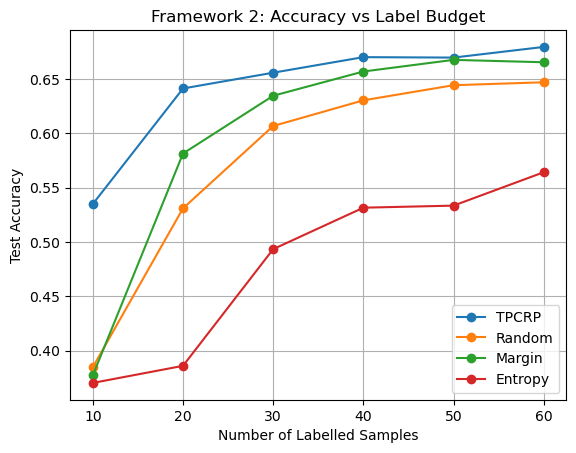

In [101]:
allDf = pd.read_csv("frameworkResults.csv")

framework2Df = allDf[allDf["framework"] == "Framework2"]

for method in framework2Df["method"].unique():
    methodDf = framework2Df[framework2Df["method"] == method]
    plt.plot(methodDf["numLabeled"], methodDf["accuracy"], marker="o", label=method)

plt.xlabel("Number of Labelled Samples")
plt.ylabel("Test Accuracy")
plt.title("Framework 2: Accuracy vs Label Budget")
plt.legend()
plt.grid(True)
plt.show()

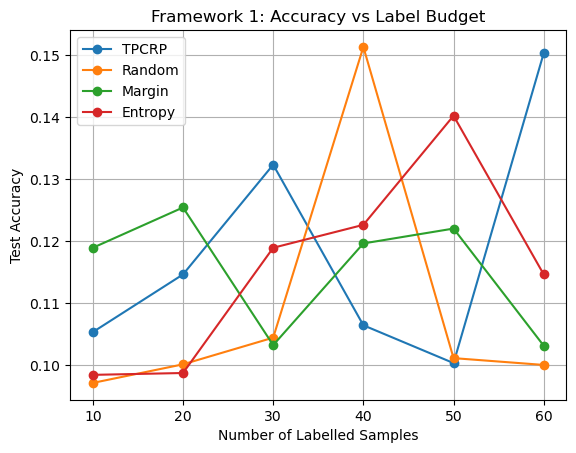

In [99]:
allDf = pd.read_csv("frameworkResults.csv")

framework1Df = allDf[allDf["framework"] == "Framework1"]

for method in framework1Df["method"].unique():
    methodDf = framework1Df[framework1Df["method"] == method]
    plt.plot(methodDf["numLabeled"], methodDf["accuracy"], marker="o", label=method)

plt.xlabel("Number of Labelled Samples")
plt.ylabel("Test Accuracy")
plt.title("Framework 1: Accuracy vs Label Budget")
plt.legend()
plt.grid(True)
plt.show()

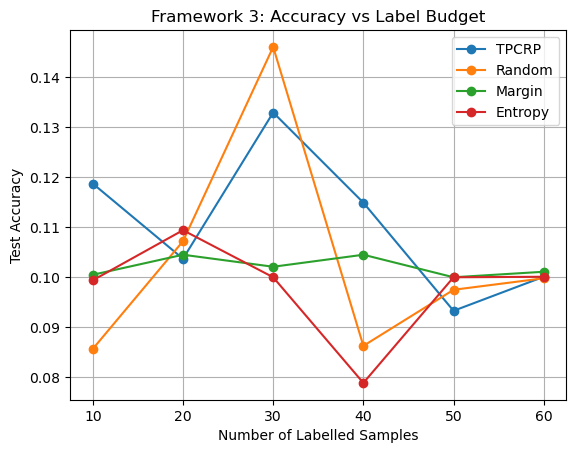

In [100]:
allDf = pd.read_csv("frameworkResults.csv")

framework3Df = allDf[allDf["framework"] == "Framework3"]

for method in framework3Df["method"].unique():
    methodDf = framework3Df[framework3Df["method"] == method]
    plt.plot(methodDf["numLabeled"], methodDf["accuracy"], marker="o", label=method)

plt.xlabel("Number of Labelled Samples")
plt.ylabel("Test Accuracy")
plt.title("Framework 3: Accuracy vs Label Budget")
plt.legend()
plt.grid(True)
plt.show()

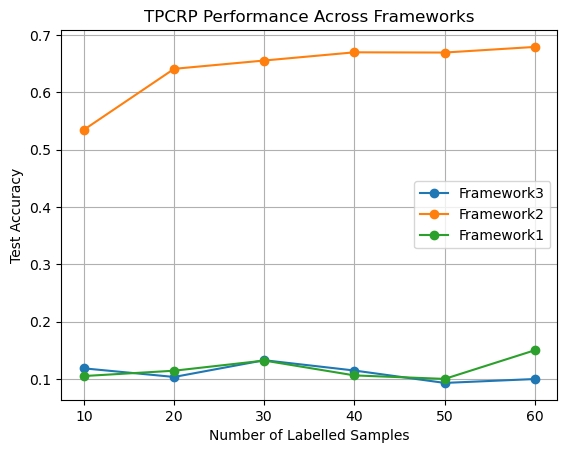

In [102]:
tpcrpDf = allDf[allDf["method"] == "TPCRP"]
for framework in tpcrpDf["framework"].unique():
    frameworkDf = tpcrpDf[tpcrpDf["framework"] == framework]
    plt.plot(frameworkDf["numLabeled"], frameworkDf["accuracy"], marker="o", label=framework)

plt.xlabel("Number of Labelled Samples")
plt.ylabel("Test Accuracy")
plt.title("TPCRP Performance Across Frameworks")
plt.legend()
plt.grid(True)
plt.show()

In [103]:
def minMaxNormalize(values):
    values = np.array(values, dtype=np.float32)
    if values.max() - values.min() < 1e-8:
        return np.ones_like(values)
    return (values - values.min()) / (values.max() - values.min())

In [104]:
def computeEntropyScores(probabilities):
    entropy = -(probabilities * torch.log(probabilities + 1e-12)).sum(dim=1)
    return entropy.cpu().numpy()

In [109]:
def selectTpcrpEntropyHybrid(trainEmbeddings, labeledIndices, unlabeledIndices, batchSize, probabilities, alpha=0.7):
    labeledIndices = [int(idx) for idx in labeledIndices]
    unlabeledIndices = [int(idx) for idx in unlabeledIndices]

    allIndices = labeledIndices + unlabeledIndices
    allEmbeddings = trainEmbeddings[allIndices].cpu().numpy()

    numClusters = len(labeledIndices) + batchSize
    kmeans = KMeans(n_clusters=numClusters, random_state=42, n_init=10)
    clusterLabels = kmeans.fit_predict(allEmbeddings)

    clusterToMembers = {}
    for pos, clusterId in enumerate(clusterLabels):
        globalIdx = allIndices[pos]
        clusterToMembers.setdefault(clusterId, []).append(globalIdx)

    uncoveredClusters = []
    for clusterId, members in clusterToMembers.items():
        hasLabeled = any(idx in labeledIndices for idx in members)
        if not hasLabeled:
            uncoveredClusters.append((clusterId, members))

    uncoveredClusters.sort(key=lambda x: len(x[1]), reverse=True)
    chosenClusters = uncoveredClusters[:batchSize]

    entropyScoresAll = computeEntropyScores(probabilities)
    probIndexMap = {idx: pos for pos, idx in enumerate(unlabeledIndices)}

    selectedIndices = []

    for clusterId, members in chosenClusters:
        unlabeledMembers = [idx for idx in members if idx in unlabeledIndices]

        if len(unlabeledMembers) == 0:
            continue

        clusterEmbeddings = trainEmbeddings[unlabeledMembers]
        typicalityScores = computeTypicality(clusterEmbeddings)

        memberEntropy = np.array([
            entropyScoresAll[probIndexMap[idx]] for idx in unlabeledMembers
        ])

        typicalityNorm = minMaxNormalize(typicalityScores)
        entropyNorm = minMaxNormalize(memberEntropy)

        hybridScores = (typicalityNorm ** alpha) * (entropyNorm ** (1 - alpha))

        bestLocal = int(np.argmax(hybridScores))
        bestGlobal = unlabeledMembers[bestLocal]

        selectedIndices.append(bestGlobal)

    return selectedIndices

In [106]:
def runFramework2HybridLoop(trainEmbeddings, trainLabels, testEmbeddings, testLabels, initialBudget=10, batchSize=10, numRounds=5, alpha=0.7):
    labeledIndices = []
    unlabeledIndices = list(range(len(trainEmbeddings)))
    results = []

    initialSelected = selectInitialTpcrp(trainEmbeddings, unlabeledIndices, initialBudget)
    labeledIndices.extend(initialSelected)
    unlabeledIndices = [idx for idx in unlabeledIndices if idx not in set(initialSelected)]

    for roundNum in range(numRounds + 1):
        linearClassifier = trainLinearClassifier(trainEmbeddings, trainLabels, labeledIndices)
        accuracy = evaluateLinearClassifier(linearClassifier, testEmbeddings, testLabels)

        results.append({
            "round": roundNum,
            "numLabeled": len(labeledIndices),
            "accuracy": accuracy
        })

        if roundNum == numRounds:
            break

        probabilities = getFramework2Probabilities(linearClassifier, trainEmbeddings, unlabeledIndices)

        newSelected = selectTpcrpEntropyHybrid(
            trainEmbeddings,
            labeledIndices,
            unlabeledIndices,
            batchSize,
            probabilities,
            alpha=alpha
        )

        labeledIndices.extend(newSelected)
        newSelectedSet = set(newSelected)
        unlabeledIndices = [idx for idx in unlabeledIndices if idx not in newSelectedSet]

    return results

In [111]:
framework2HybridResults = runFramework2HybridLoop(
    trainEmbeddings,
    trainLabels,
    testEmbeddings,
    testLabels,
    initialBudget=10,
    batchSize=10,
    numRounds=5,
    alpha=0.7
)

print("Framework 2 TPCRP-Entropy Results:")
for row in framework2HybridResults:
    print(row)

Framework 2 TPCRP-Entropy Results:
{'round': 0, 'numLabeled': 10, 'accuracy': 0.5336999893188477}
{'round': 1, 'numLabeled': 20, 'accuracy': 0.6172000169754028}
{'round': 2, 'numLabeled': 30, 'accuracy': 0.6600000262260437}
{'round': 3, 'numLabeled': 40, 'accuracy': 0.6679999828338623}
{'round': 4, 'numLabeled': 50, 'accuracy': 0.683899998664856}
{'round': 5, 'numLabeled': 60, 'accuracy': 0.6934999823570251}


In [112]:
framework2HybridDf = pd.DataFrame(framework2HybridResults)
framework2HybridDf["method"] = "TPCRP-Entropy"
framework2HybridDf["framework"] = "Framework2"

framework2TpcrpDf = framework2Df[framework2Df["method"] == "TPCRP"].copy()
framework2RandomDf = framework2Df[framework2Df["method"] == "Random"].copy()
framework2MarginDf = framework2Df[framework2Df["method"] == "Margin"].copy()
framework2EntropyDf = framework2Df[framework2Df["method"] == "Entropy"].copy()
updatedFramework2Df = pd.concat([framework2TpcrpDf, framework2RandomDf, framework2MarginDf, framework2EntropyDf, framework2HybridDf], ignore_index=True)
updatedFramework2Df.to_csv("framework2UpdatedResults.csv", index=False)